Antal utan m-komponent i träningsdatan: 17903
Antal med m-komponent i träningsdatan: 2553
Total parameters: 320,194
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   0 | train: 0.3960 | val: 0.1536 | acc: 98.17% | AUC: 0.962  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   1 | train: 0.1763 | val: 0.0841 | acc: 98.14% | AUC: 0.992  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   2 | train: 0.1347 | val: 0.0650 | acc: 98.66% | AUC: 0.994  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   3 | train: 0.1173 | val: 0.0826 | acc: 97.69% | AUC: 0.994  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_dataset_experiment.pth
Epoch   4 | train: 0.0952 | val: 0.0834 | acc: 97.69% | AUC: 0.995  | LR: 0.001
Epoch   5 | train: 0.0839 | val: 0.0703 | acc: 98.02% | AUC: 0.994  | LR: 0.001
Epoch   6 | train: 0.0748 | val: 0.0549 | acc: 98.45% 

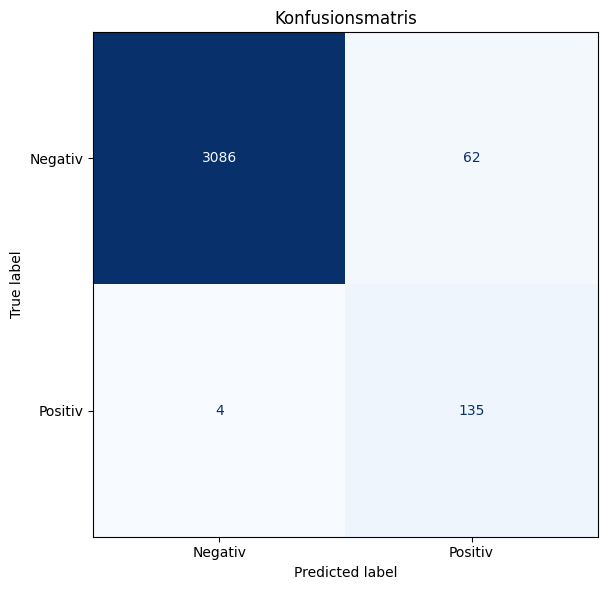

AUC: 0.9957835510498843
Accuracy:  97.99%
FN-rate:   2.88%  (farliga missade fall)
FP-rate:   1.97%  (onödiga larm)
Sensitivitet:   97.12%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   98.03%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9958


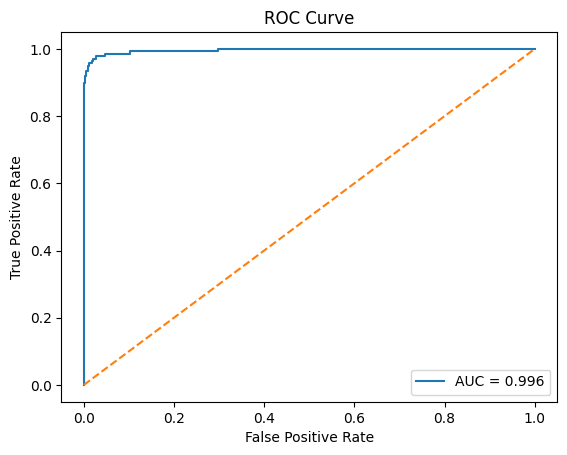

In [ ]:
import duckdb
import torch
from functions.analyte import ANALYTES
from networks.cnn_dataset_experiment import CNNModel
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE observation_nr = 1
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

#df['value'] = df['value'].apply(lambda x: x / np.max(x))

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index
train_rows = train_rows.drop(drop_indices)

val_rows = val_rows[val_rows['label'].isin([0,1])]
train_rows = train_rows[train_rows['label'].isin([0,1])]



print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")


CNN = CNNModel()
protein_cols = [a.col for a in ANALYTES[:8]]
train_rows = train_rows.dropna(subset=protein_cols)
val_rows = val_rows.dropna(subset=protein_cols)
test_rows = test_rows.dropna(subset=protein_cols)

def build_X(rows):
    return np.concatenate([
        np.array(rows['value'].tolist(),  dtype=np.float32),
        np.array(rows['fractions'].tolist(),  dtype=np.float32),  # (n, 6)
        np.array(rows['boundaries'].tolist(), dtype=np.float32),  # (n, 12)
        np.array(rows[protein_cols].values,   dtype=np.float32),  # (n, 8)
    ], axis=1)

X_train = build_X(train_rows)
X_val   = build_X(val_rows)

# Skala bara features efter index 300, fit bara på träning
scaler = StandardScaler()
X_train[:,:] = scaler.fit_transform(X_train[:,:])
X_val[:,:] = scaler.transform(X_val[:,:])

y_train = torch.tensor(np.array(train_rows['label'].values, dtype=np.int64))
y_val   = torch.tensor(np.array(val_rows['label'].values,   dtype=np.int64))

X_train, X_val = map(torch.tensor, [X_train, X_val])

train_dl = DataLoader(TensorDataset(X_train, y_train, torch.tensor(train_rows['row_id'].to_numpy())), batch_size=512, shuffle=True)
val_dl   = DataLoader(TensorDataset(X_val,   y_val,   torch.tensor(val_rows['row_id'].to_numpy())),   batch_size=512)

CNN.reset_weights()
CNN.retrain(train_dl,val_dl,patience=15)



"""Beräknar P(M-komponent) och skriver till df['cnn_probability']."""
CNN.model.load_state_dict(torch.load(CNN.model_path, weights_only=True))
CNN.model.eval()
all_probs = []
with torch.no_grad():
    for batch in val_dl:
        inputs = batch[0].to(device)
        logits = CNN.model(inputs)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs.append(probs.cpu().numpy())

val_rows['cnn_probability'] = np.concatenate(all_probs)
_ = CNN.evaluate(val_rows)

In [2]:


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.7).index
k_fold_rows = k_fold_rows.drop(drop_indices)
print(f"Totalt antal utan m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

test_rows  = df[df['set'] == 'test']


CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows,scaling_indices=range(300,318),filename='feature_scaling')

Totalt antal utan m-komponent i K-fold poolen: 18848
Totalt antal med m-komponent i K-fold poolen: 2692
Total parameters: 320,194
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
  -> ny bästa modell sparad till ../models/feature_scaling_fold1.pth
Epoch   0 | train: 0.5246 | val: 0.5383 | acc: 92.53% | AUC: 0.861  | LR: 0.001
  -> ny bästa modell sparad till ../models/feature_scaling_fold1.pth
Epoch   1 | train: 0.2806 | val: 0.2616 | acc: 95.68% | AUC: 0.953  | LR: 0.001
  -> ny bästa modell sparad till ../models/feature_scaling_fold1.pth
Epoch   2 | train: 0.1934 | val: 0.1909 | acc: 95.54% | AUC: 0.975  | LR: 0.001
  -> ny bästa modell sparad till ../models/feature_scaling_fold1.pth
Epoch   3 | train: 0.1721 | val: 0.1889 | acc: 94.89% | AUC: 0.977  | LR: 0.001
  -> ny bästa modell sparad till ../models/feature_scaling_fold1.pth
Epoch   4 | train: 0.1477 | val: 0.1751 | acc: 97.35% | AUC: 0.986  | LR: 0.001
Epoch   5 | train: 0.1290 | val: 0.1958 | acc: 97.21% | AUC: 0.985  | LR

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.117779,0.141159,95.589601,0.990147,0.957537,0.944444,1804,80,15,255
1,2,0.081621,0.100715,96.657382,0.992020,0.970807,0.937037,1829,55,17,253
2,3,0.024540,0.207179,97.400186,0.984700,0.984615,0.899628,1856,29,27,242
3,4,0.061159,0.144291,97.214485,0.990252,0.975066,0.951673,1838,47,13,256
4,5,0.058624,0.120575,97.539461,0.990841,0.983554,0.918216,1854,31,22,247
5,6,0.092901,0.088673,97.446611,0.995657,0.976658,0.959108,1841,44,11,258
6,7,0.067432,0.109470,97.353760,0.991141,0.977188,0.947955,1842,43,14,255
7,8,0.106715,0.184844,94.150418,0.981525,0.944297,0.921933,1780,105,21,248
8,9,0.089897,0.189745,97.632312,0.986175,0.988329,0.892193,1863,22,29,240
9,10,0.088606,0.123649,97.260910,0.990303,0.979310,0.925651,1846,39,20,249


In [3]:


CNN = CNNModel()
CNN.retrain_with_k_fold_no_scaling(k_fold_rows,scaling_indices=range(0,0),filename='no_scaling')

Total parameters: 320,194
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
  -> ny bästa modell sparad till ../models/no_scaling_fold1.pth
Epoch   0 | train: 0.4540 | val: 0.4239 | acc: 94.52% | AUC: 0.916  | LR: 0.001
  -> ny bästa modell sparad till ../models/no_scaling_fold1.pth
Epoch   1 | train: 0.2180 | val: 0.2401 | acc: 94.01% | AUC: 0.968  | LR: 0.001
  -> ny bästa modell sparad till ../models/no_scaling_fold1.pth
Epoch   2 | train: 0.1650 | val: 0.2221 | acc: 92.71% | AUC: 0.976  | LR: 0.001
  -> ny bästa modell sparad till ../models/no_scaling_fold1.pth
Epoch   3 | train: 0.1459 | val: 0.1651 | acc: 97.54% | AUC: 0.982  | LR: 0.001
  -> ny bästa modell sparad till ../models/no_scaling_fold1.pth
Epoch   4 | train: 0.1242 | val: 0.1470 | acc: 96.70% | AUC: 0.987  | LR: 0.001
Epoch   5 | train: 0.1156 | val: 0.1488 | acc: 97.59% | AUC: 0.986  | LR: 0.001
Epoch   6 | train: 0.1114 | val: 0.1719 | acc: 95.96% | AUC: 0.982  | LR: 0.001
  -> ny bästa modell sparad till ../model

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.074868,0.138015,97.818013,0.989166,0.984607,0.933333,1855,29,18,252
1,2,0.114712,0.113135,97.353760,0.990179,0.982484,0.911111,1851,33,24,246
2,3,0.066170,0.139646,96.100279,0.989176,0.964456,0.936803,1818,67,17,252
3,4,0.103047,0.138061,96.935933,0.987988,0.974005,0.936803,1836,49,17,252
4,5,0.104629,0.118361,97.307335,0.990029,0.982493,0.907063,1852,33,25,244
5,6,0.056292,0.088249,96.750232,0.994342,0.965517,0.981413,1820,65,5,264
6,7,0.078827,0.127706,97.260910,0.988560,0.979841,0.921933,1847,38,21,248
7,8,0.079969,0.170780,97.028784,0.985398,0.980902,0.895911,1849,36,28,241
8,9,0.087540,0.176995,97.307335,0.984140,0.980371,0.921933,1848,37,21,248
9,10,0.084843,0.114582,95.821727,0.989609,0.960743,0.940520,1811,74,16,253


In [4]:
CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows,scaling_indices=range(0,300),filename='time_series_scaling')

Total parameters: 320,194
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
  -> ny bästa modell sparad till ../models/time_series_scaling_fold1.pth
Epoch   0 | train: 0.4153 | val: 0.3246 | acc: 95.45% | AUC: 0.940  | LR: 0.001
  -> ny bästa modell sparad till ../models/time_series_scaling_fold1.pth
Epoch   1 | train: 0.1985 | val: 0.1951 | acc: 96.15% | AUC: 0.971  | LR: 0.001
  -> ny bästa modell sparad till ../models/time_series_scaling_fold1.pth
Epoch   2 | train: 0.1753 | val: 0.2159 | acc: 97.54% | AUC: 0.979  | LR: 0.001
  -> ny bästa modell sparad till ../models/time_series_scaling_fold1.pth
Epoch   3 | train: 0.1336 | val: 0.1588 | acc: 97.35% | AUC: 0.985  | LR: 0.001
Epoch   4 | train: 0.1224 | val: 0.1645 | acc: 97.54% | AUC: 0.985  | LR: 0.001
Epoch   5 | train: 0.1039 | val: 0.1650 | acc: 96.70% | AUC: 0.984  | LR: 0.001
  -> ny bästa modell sparad till ../models/time_series_scaling_fold1.pth
Epoch   6 | train: 0.0870 | val: 0.1752 | acc: 97.40% | AUC: 0.986  | LR: 0.

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.010291,0.189424,97.818013,0.989551,0.989384,0.900000,1864,20,27,243
1,2,0.063520,0.107954,97.910864,0.990147,0.987261,0.922222,1860,24,21,249
2,3,0.110847,0.196507,95.032498,0.970848,0.957560,0.899628,1805,80,27,242
3,4,0.087323,0.167606,96.796657,0.984836,0.977188,0.903346,1842,43,26,243
4,5,0.109843,0.146470,97.260910,0.987104,0.980371,0.918216,1848,37,22,247
5,6,0.089741,0.105832,95.543175,0.994922,0.952785,0.973978,1796,89,7,262
6,7,0.025912,0.179163,96.425255,0.979044,0.970822,0.918216,1830,55,22,247
7,8,0.057168,0.189396,95.868152,0.981643,0.964987,0.914498,1819,66,23,246
8,9,0.108994,0.229647,96.332405,0.975599,0.974536,0.884758,1837,48,31,238
9,10,0.085337,0.125067,96.518106,0.986761,0.970822,0.925651,1830,55,20,249


In [5]:
CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows,scaling_indices=range(326),filename='full_scaling')

Total parameters: 320,194
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
  -> ny bästa modell sparad till ../models/full_scaling_fold1.pth
Epoch   0 | train: 0.3571 | val: 0.3344 | acc: 91.92% | AUC: 0.919  | LR: 0.001
  -> ny bästa modell sparad till ../models/full_scaling_fold1.pth
Epoch   1 | train: 0.2058 | val: 0.2163 | acc: 92.11% | AUC: 0.972  | LR: 0.001
  -> ny bästa modell sparad till ../models/full_scaling_fold1.pth
Epoch   2 | train: 0.1738 | val: 0.1844 | acc: 94.43% | AUC: 0.977  | LR: 0.001
Epoch   3 | train: 0.1373 | val: 0.1999 | acc: 96.56% | AUC: 0.976  | LR: 0.001
  -> ny bästa modell sparad till ../models/full_scaling_fold1.pth
Epoch   4 | train: 0.1160 | val: 0.1523 | acc: 97.31% | AUC: 0.984  | LR: 0.001
Epoch   5 | train: 0.1074 | val: 0.1948 | acc: 96.70% | AUC: 0.980  | LR: 0.001
  -> ny bästa modell sparad till ../models/full_scaling_fold1.pth
Epoch   6 | train: 0.1040 | val: 0.2287 | acc: 97.77% | AUC: 0.984  | LR: 0.001
Epoch   7 | train: 0.0793 | val

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.008860,0.235673,97.353760,0.987670,0.985138,0.892593,1856,28,29,241
1,2,0.125707,0.116100,96.239554,0.989445,0.964437,0.948148,1817,67,14,256
2,3,0.078561,0.175873,95.403900,0.979350,0.961804,0.899628,1813,72,27,242
3,4,0.031490,0.233330,97.121634,0.981673,0.984615,0.877323,1856,29,33,236
4,5,0.047782,0.134320,97.168059,0.988855,0.977719,0.929368,1843,42,19,250
5,6,0.129090,0.119138,98.050139,0.991676,0.992573,0.895911,1871,14,28,241
6,7,0.116469,0.157952,96.982358,0.983592,0.983024,0.877323,1853,32,33,236
7,8,0.050241,0.179734,97.400186,0.982401,0.982493,0.914498,1852,33,23,246
8,9,0.009336,0.304549,97.678737,0.981482,0.988329,0.895911,1863,22,28,241
9,10,0.038590,0.148049,95.728877,0.987765,0.961804,0.925651,1813,72,20,249


In [6]:
CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows,scaling_indices=range(300,326),filename='features_and_proteins')

Total parameters: 320,194
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
  -> ny bästa modell sparad till ../models/features_and_proteins_fold1.pth
Epoch   0 | train: 0.4460 | val: 0.4260 | acc: 94.29% | AUC: 0.942  | LR: 0.001
  -> ny bästa modell sparad till ../models/features_and_proteins_fold1.pth
Epoch   1 | train: 0.2040 | val: 0.1873 | acc: 95.13% | AUC: 0.974  | LR: 0.001
  -> ny bästa modell sparad till ../models/features_and_proteins_fold1.pth
Epoch   2 | train: 0.1716 | val: 0.1812 | acc: 96.52% | AUC: 0.979  | LR: 0.001
  -> ny bästa modell sparad till ../models/features_and_proteins_fold1.pth
Epoch   3 | train: 0.1482 | val: 0.1723 | acc: 96.98% | AUC: 0.984  | LR: 0.001
  -> ny bästa modell sparad till ../models/features_and_proteins_fold1.pth
Epoch   4 | train: 0.1341 | val: 0.1526 | acc: 96.70% | AUC: 0.986  | LR: 0.001
  -> ny bästa modell sparad till ../models/features_and_proteins_fold1.pth
Epoch   5 | train: 0.1181 | val: 0.1609 | acc: 97.40% | AUC: 0.988  | L

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.069460,0.143496,97.725162,0.989422,0.984607,0.925926,1855,29,20,250
1,2,0.078307,0.111841,98.282266,0.991891,0.992569,0.914815,1870,14,23,247
2,3,0.055910,0.138912,96.796657,0.987607,0.972414,0.936803,1833,52,17,252
3,4,0.081195,0.209271,97.957289,0.990429,0.992573,0.888476,1871,14,30,239
4,5,0.029014,0.190794,97.307335,0.988433,0.982493,0.907063,1852,33,25,244
5,6,0.064198,0.083542,97.353760,0.995724,0.975597,0.959108,1839,46,11,258
6,7,0.104709,0.121105,97.585887,0.990392,0.985146,0.910781,1857,28,24,245
7,8,0.133361,0.169945,95.218199,0.981695,0.958090,0.910781,1806,79,24,245
8,9,0.117625,0.170498,96.982358,0.985304,0.980902,0.892193,1849,36,29,240
9,10,0.142227,0.148103,96.564531,0.986546,0.975597,0.895911,1839,46,28,241
